K     | Note Prédite | Résultat
-----------------------------------
1     | 9.00         | Échec
2     | 8.50         | Échec
3     | 8.00         | Échec
4     | 8.75         | Échec
5     | 10.50        | Réussite
6     | 10.42        | Réussite
7     | 10.36        | Réussite
8     | 10.19        | Réussite
9     | 10.28        | Réussite
10    | 10.05        | Réussite


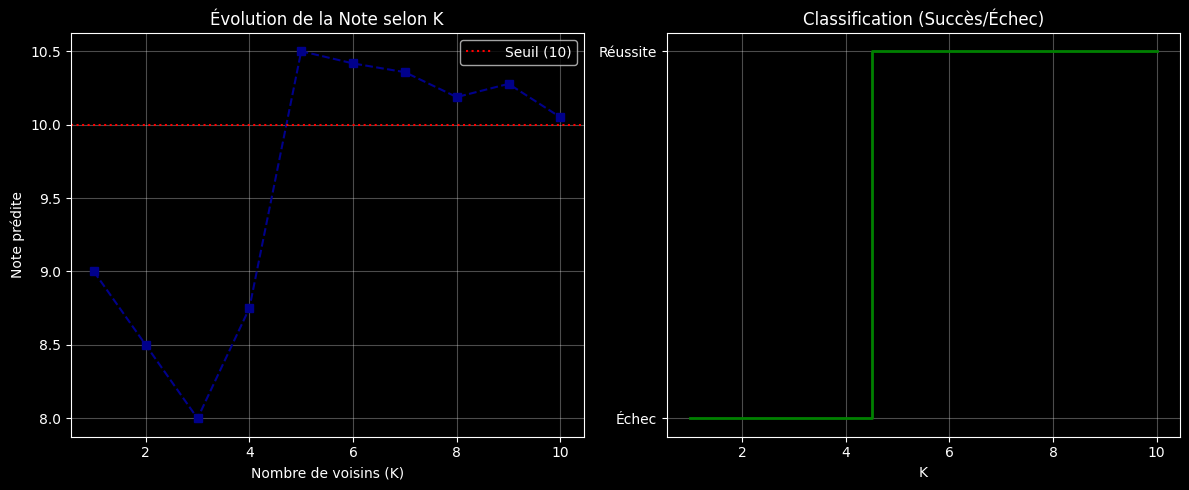

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#------------------------------------------
# 1. DATASET COMPLET
#------------------------------------------
# Caractéristiques : [Heures, Motivation, Absences, Score_Précédent, Bonus, Fatigue]
import numpy as np

X = np.array([
    [2, 5, 8, 20, 0, 6],
    [4, 6, 6, 40, 2, 5],
    [6, 7, 5, 60, 3, 4],
    [8, 7, 4, 80, 4, 3],
    [10, 8, 3, 90, 5, 2],

    [3, 4, 9, 30, 0, 7],
    [7, 6, 5, 70, 3, 4],
    [5, 5, 6, 50, 2, 5],
    [9, 8, 4, 85, 4, 3],
    [1, 3, 9, 15, 1, 8],

    [6, 6, 5, 65, 3, 4],
    [7, 7, 4, 75, 3, 3],
    [8, 8, 3, 88, 4, 2],
    [2, 4, 8, 25, 1, 6],
    [3, 5, 7, 35, 2, 6],

    [4, 7, 6, 45, 2, 5],
    [5, 6, 6, 55, 3, 4],
    [6, 8, 5, 68, 3, 3],
    [7, 5, 5, 72, 4, 3],
    [9, 7, 4, 82, 4, 2],

    [10, 9, 3, 95, 5, 1],
    [2, 3, 9, 10, 1, 9],
    [3, 4, 8, 28, 2, 7],
    [6, 5, 6, 60, 3, 4],
    [7, 6, 5, 70, 3, 3],

    [8, 7, 4, 78, 4, 2],
    [9, 8, 3, 88, 5, 2],

    [1, 2, 9, 12, 0, 9],
    [2, 6, 7, 22, 1, 7],
    [3, 7, 6, 32, 1, 6],
    [4, 8, 5, 42, 2, 5],
    [5, 9, 4, 52, 2, 4],

    [6, 3, 8, 62, 3, 5],
    [7, 4, 7, 72, 3, 4],
    [8, 5, 6, 82, 4, 3],
    [9, 6, 5, 92, 5, 2],
    [10, 7, 4, 98, 5, 1],

    [2, 5, 7, 18, 0, 8],
    [3, 6, 6, 28, 1, 7],
    [4, 7, 5, 38, 2, 6],
    [5, 8, 4, 48, 2, 5],
    [6, 9, 3, 58, 3, 4],

    [7, 3, 9, 68, 3, 6],
    [8, 4, 8, 78, 4, 5],
    [9, 5, 7, 88, 4, 4],
    [10, 6, 6, 96, 5, 3],
    [1, 7, 8, 14, 1, 8]
])

import numpy as np

notes = np.array([
    10, 13, 15, 17, 18.5, 11, 16, 12, 17, 9, 14, 15, 18, 10, 11,
    13, 14, 15, 16, 17, 19, 8, 9, 14, 15, 16, 17,

    # ajout pour équilibrer la distribution
    7, 8, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5,
    15.5, 16.5, 17.5, 18, 19, 20,

    # quelques valeurs réalistes supplémentaires
    6, 7.5, 8.5, 9, 10, 11, 12, 13
])

#------------------------------------------
# 2. PARAMÈTRES ET NORMALISATION
#------------------------------------------
SEUIL_REUSSITE = 10

# Normalisation sur l'ensemble des données
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_norm = (X - X_mean) / X_std

#------------------------------------------
# 3. FONCTIONS KNN
#------------------------------------------
def distance_manhattan(x1, x2):
    return np.sum(np.abs(x1 - x2))

def knn_predict(X_train, notes_train, x_test, K):
    distances = []
    for i in range(len(X_train)):
        d = distance_manhattan(x_test, X_train[i])
        distances.append((d, notes_train[i]))

    # Trier par distance
    distances.sort(key=lambda x: x[0])
    k_voisins = distances[:K]

    # Moyenne des notes des K voisins
    moyenne_notes = np.mean([v[1] for v in k_voisins])
    return moyenne_notes

#------------------------------------------
# 4. TEST SUR UN ÉTUDIANT (Profil "Échec")
#------------------------------------------
# On simule un étudiant qui a peu travaillé pour voir le résultat "Échec"
etudiant_test = np.array([[2, 3, 9, 15, 0, 8]])
x_test_norm = (etudiant_test - X_mean) / X_std
x_test_norm = x_test_norm.flatten() # Conversion en vecteur 1D

#------------------------------------------
# 5. EXÉCUTION ET AFFICHAGE
#------------------------------------------
liste_k = list(range(1, 11))
pred_notes = []
pred_classes = []

print(f"{'K':<5} | {'Note Prédite':<12} | {'Résultat'}")
print("-" * 35)

for K in liste_k:
    note_finale = knn_predict(X_norm, notes, x_test_norm, K)

    # Détermination de la classe (1 pour Réussite, 0 pour Échec)
    classe = 1 if note_finale >= SEUIL_REUSSITE else 0
    status = "Réussite" if classe == 1 else "Échec"

    pred_notes.append(note_finale)
    pred_classes.append(classe)

    print(f"{K:<5} | {note_finale:<12.2f} | {status}")

#------------------------------------------
# 6. VISUALISATION
#------------------------------------------
plt.figure(figsize=(12, 5))

# Graphique de la Régression
plt.subplot(1, 2, 1)
plt.plot(liste_k, pred_notes, marker='s', color='darkblue', linestyle='--')
plt.axhline(y=SEUIL_REUSSITE, color='red', linestyle=':', label=f'Seuil ({SEUIL_REUSSITE})')
plt.title("Évolution de la Note selon K")
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Note prédite")
plt.legend()
plt.grid(alpha=0.3)

# Graphique de la Classification
plt.subplot(1, 2, 2)
plt.step(liste_k, pred_classes, where='mid', color='green', linewidth=2)
plt.yticks([0, 1], ["Échec", "Réussite"])
plt.title("Classification (Succès/Échec)")
plt.xlabel("K")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()